In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder


In [4]:
df = pd.read_csv("diabetes_risk.csv")
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


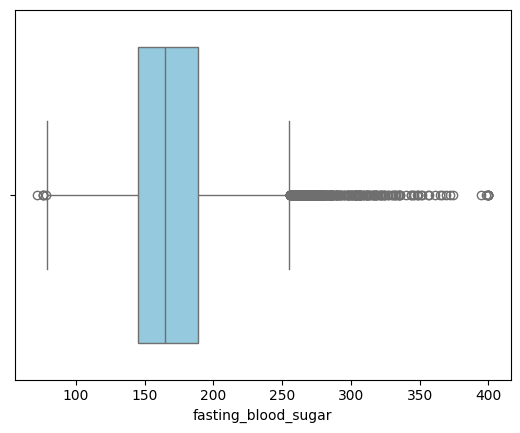

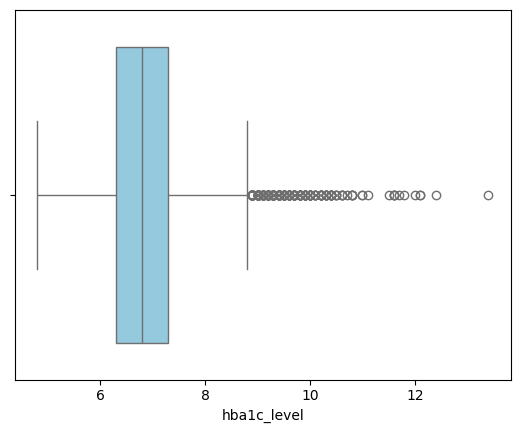

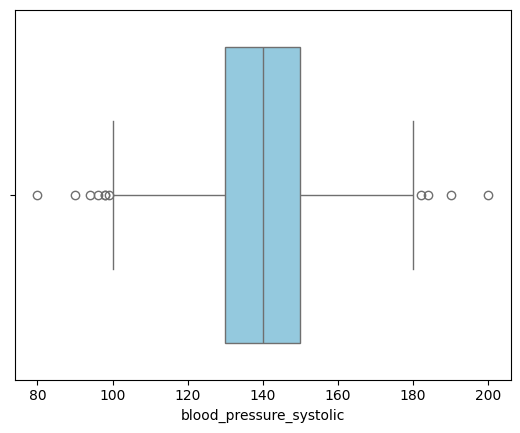

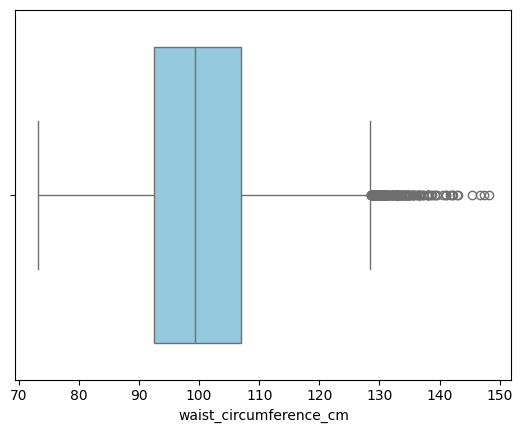

In [5]:
sns.boxplot(x=df['fasting_blood_sugar'], color='skyblue')
plt.show()
sns.boxplot(x=df['hba1c_level'], color='skyblue')
plt.show()
sns.boxplot(x=df['blood_pressure_systolic'], color='skyblue')
plt.show()
sns.boxplot(x=df['waist_circumference_cm'], color='skyblue')
plt.show()



In [6]:
df.info()
df['diabetes_risk'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

,count
diabetes_risk,
Low,9000
Moderate,3750
High,2250


/tmp/ipykernel_2572/2594077619.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diabetes_risk', data=df, palette='Set2')


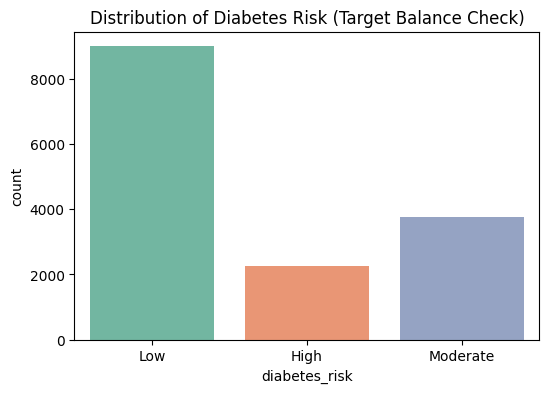

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='diabetes_risk', data=df, palette='Set2')
plt.title('Distribution of Diabetes Risk (Target Balance Check)')
plt.show()

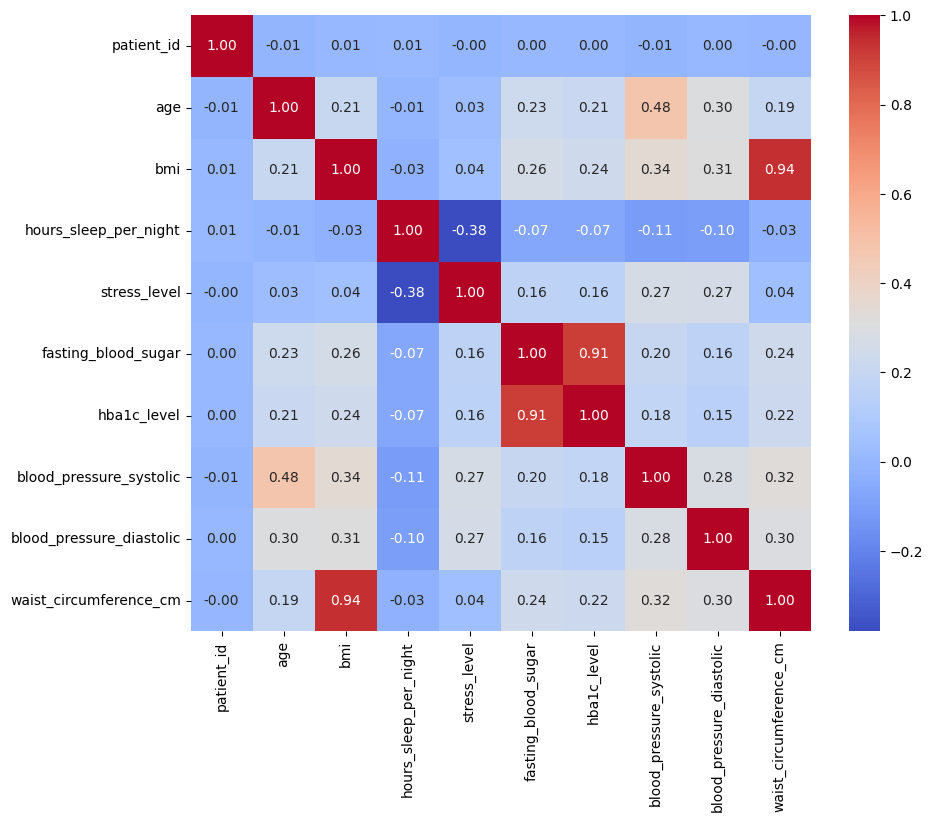

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('')
plt.show()


In [9]:
df.columns = df.columns.str.strip()
df =df.drop(columns=['patient_id','city','income_bracket'])

In [10]:
print(df.describe())

                age           bmi  hours_sleep_per_night  stress_level  \
count  15000.000000  15000.000000           15000.000000  15000.000000   
mean      44.333667     23.062260               7.309860      5.941200   
std       10.383753      4.046391               1.109372      2.148406   
min       18.000000     15.000000               3.000000      1.000000   
25%       38.000000     20.100000               6.700000      4.000000   
50%       45.000000     22.700000               7.000000      6.000000   
75%       52.000000     25.600000               8.000000      7.000000   
max       80.000000     40.800000              12.000000     10.000000   

       fasting_blood_sugar   hba1c_level  blood_pressure_systolic  \
count         15000.000000  15000.000000             15000.000000   
mean            168.789933      6.878387               139.496200   
std              38.365822      0.843276                12.660785   
min              72.000000      4.800000                8

In [11]:
df.isnull().sum()
df=df.drop(columns=['alcohol_consumption'])
df=df.dropna()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['pulse_pressure'] = df['blood_pressure_systolic'] - df['blood_pressure_diastolic']
df['sugar_interaction'] = df['fasting_blood_sugar'] * df['hba1c_level']

In [14]:
df = pd.get_dummies(df, columns=['gender','family_history_diabetes','diet_type','smoking_status'], drop_first=True)

In [15]:
x=df.drop(columns=['diabetes_risk'])
y=df['diabetes_risk']

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
object_cols = ['physical_activity_level']
ordinal_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
x_train[object_cols] = ordinal_enc.fit_transform(x_train[object_cols])
x_test[object_cols] = ordinal_enc.transform(x_test[object_cols])
scaler = RobustScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

## Modeling & Comparison

We train 5 models  and evaluate all of them using Accuracy, Precision, Recall, F1-score , and Confusion Matrix.

In [17]:
# Import classifiers and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

### 1. Logistic Regression — Baseline

In [18]:
# Train baseline Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(x_train, y_train)
y_pred_log_reg = log_reg.predict(x_test)

### 2. KNN

In [19]:
# Train K-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

### 3. SVM

In [20]:
# Train Support Vector Machine model
svm = SVC(kernel='rbf', random_state=42)
svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)

### 4. Decision Tree

In [21]:
# Train Decision Tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

### 5. Random Forest

In [22]:
# Train Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

### Comparison Table — Accuracy / Precision (macro) / Recall (macro) / F1 (macro)

In [23]:
# Collect all model predictions in one dictionary
models_preds = {
    'Logistic Regression': y_pred_log_reg,
    'KNN': y_pred_knn,
    'SVM': y_pred_svm,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
}

# Compute metrics for each model on the same test set
results = []
for name, y_pred in models_preds.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1-score (macro)': f1_score(y_test, y_pred, average='macro'),
    })

# Build a comparison dataframe, sorted by F1-score
results_df = pd.DataFrame(results).sort_values(by='F1-score (macro)', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,Logistic Regression,0.793531,0.751048,0.724596,0.736228
1,SVM,0.795251,0.763298,0.716927,0.735943
2,Random Forest,0.790778,0.746902,0.719961,0.732004
3,KNN,0.750172,0.680817,0.665541,0.672201
4,Decision Tree,0.723675,0.656492,0.649942,0.652991


### Bar Chart Comparison

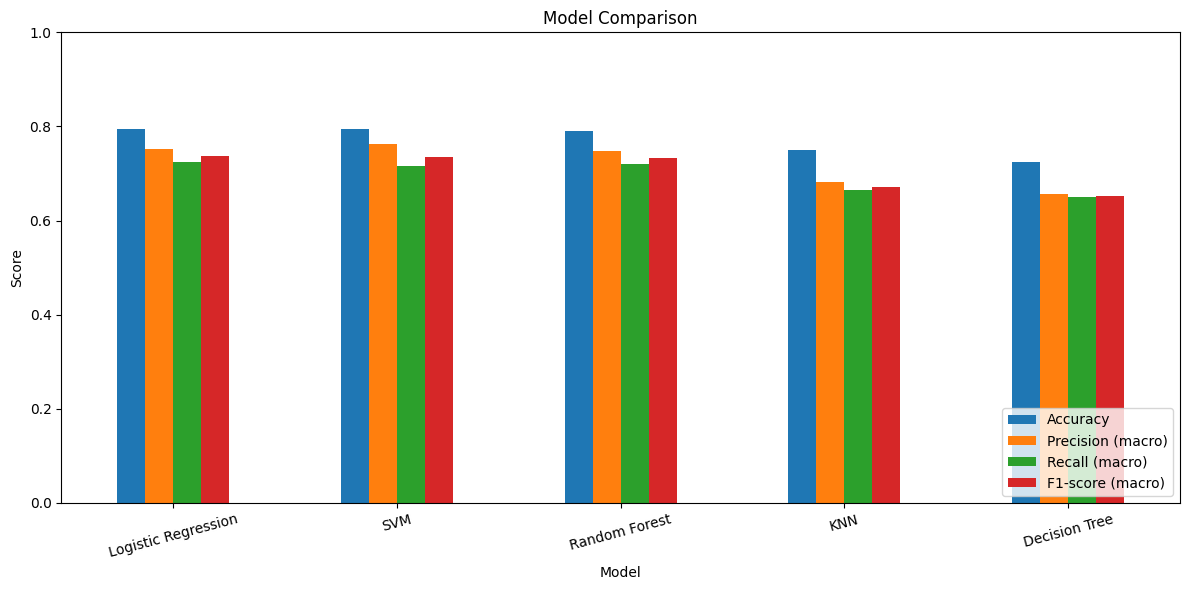

In [24]:
# Plot all metrics side by side for each model
results_df.set_index('Model')[['Accuracy','Precision (macro)','Recall (macro)','F1-score (macro)']].plot(
    kind='bar', figsize=(12,6)
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Confusion Matrices

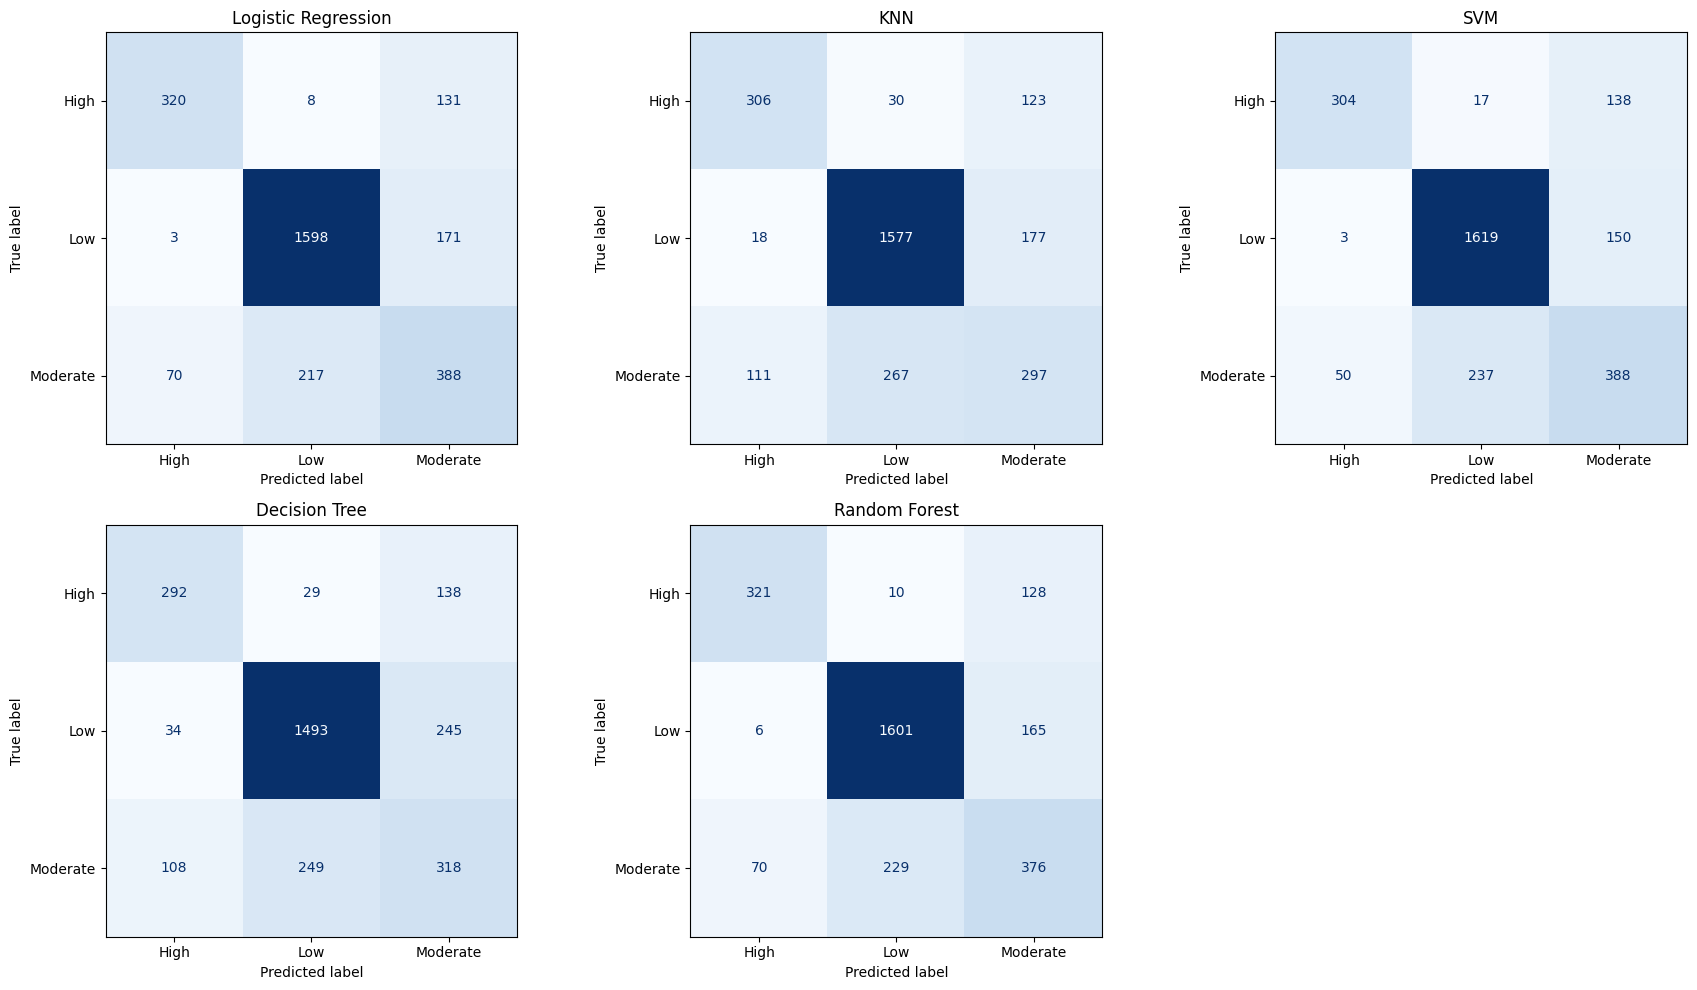

In [25]:
# Plot confusion matrix for each model in a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

class_labels = sorted(y_test.unique())

for ax, (name, y_pred) in zip(axes, models_preds.items()):
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

# Hide the unused 6th subplot
for i in range(len(models_preds), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### Detailed Classification Reports (per model)

In [26]:
# Print a full classification report for each model
for name, y_pred in models_preds.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred))
    print()

===== Logistic Regression =====
              precision    recall  f1-score   support

        High       0.81      0.70      0.75       459
         Low       0.88      0.90      0.89      1772
    Moderate       0.56      0.57      0.57       675

    accuracy                           0.79      2906
   macro avg       0.75      0.72      0.74      2906
weighted avg       0.79      0.79      0.79      2906


===== KNN =====
              precision    recall  f1-score   support

        High       0.70      0.67      0.68       459
         Low       0.84      0.89      0.87      1772
    Moderate       0.50      0.44      0.47       675

    accuracy                           0.75      2906
   macro avg       0.68      0.67      0.67      2906
weighted avg       0.74      0.75      0.74      2906


===== SVM =====
              precision    recall  f1-score   support

        High       0.85      0.66      0.75       459
         Low       0.86      0.91      0.89      1772
    Moder